In [ ]:
import numpy as np
import cmath
import math
import sympy as spa
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir

### Oefening 58
Bij een fabriek die klinkers maakt, wil men de maatvastheid onderzoeken van de geproduceerde klinkers. Daarvoor werd een steekproef gedaan en de lengte gemeten.

12 13 14 16 15 18 19 10 11 12 13 14 15 13 14 12

a) Presenteer een histogram van deze gegevens.

b) Vind de mediaan, de interkwartielafstand, de modus, het gemiddelde, variantie en het 10% percentiel.

(array([1., 1., 3., 3., 3., 2., 1., 0., 1., 1.]),
 array([10. , 10.9, 11.8, 12.7, 13.6, 14.5, 15.4, 16.3, 17.2, 18.1, 19. ]),
 <BarContainer object of 10 artists>)

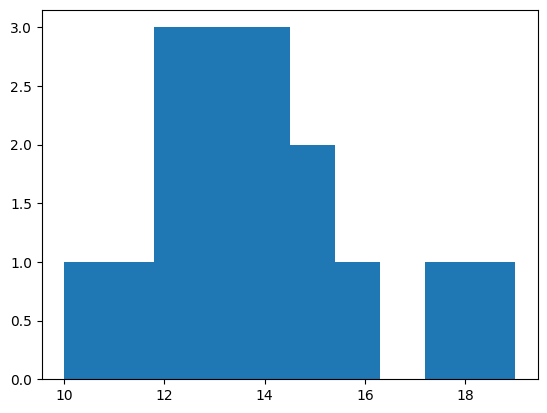

In [2]:
steekproef = [12,13,14,16,15,18,19,10,11,12,13,14,15,13,14,12]
plt.hist(steekproef)

In [4]:
print(f"mediaan =  {np.median(steekproef)}")
print(f"gemiddelde = {np.mean(steekproef)}")
print(f"variantie = {np.var(steekproef,ddof=1)}")
print(f"10% percentiel = {np.percentile(steekproef,10)}")
print(f"modus = {stat.mode(steekproef)}")
print(f"IKA = {spstat.iqr(steekproef)}")

mediaan =  13.5
gemiddelde = 13.8125
variantie = 5.7625
10% percentiel = 11.5
modus = 12
IKA = 3.0


### Oefening 63
De resultaten (/100) behaald door een selectie van 10 studenten op het examen wiskunde en economie worden gegeven in onderstaande tabel.

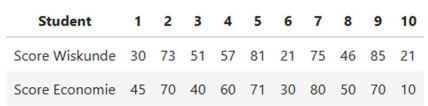

a) Wat is de gemiddelde score voor het examen wiskunde bij deze 10 studenten?

b) Schat de verwachte score voor het examen economie. Wat is daarbij de standaardfout?

c) Bij welk examen is de variantie het grootst voor deze groep studenten?

d) Maak een scatterplot waarbij je de score voor wiskunde uitzet ten opzichte van de score voor economie.

In [5]:
W=[30,73,51,57,81,21,75,46,85,21]
E=[45,70,40,60,71,30,80,50,70,10]
print(f"voor wiskunde scoort men gemiddeld {np.mean(W)}")

voor wiskunde scoort men gemiddeld 54.0


In [6]:
gemE=np.mean(E)
varE=np.var(E,ddof=1)
stdafwE=np.sqrt(varE)
stdfoutE=stdafwE/np.sqrt(10)
print(f"voor economie is de verwachte score {gemE} met standaardfout {stdfoutE}")

voor economie is de verwachte score 52.6 met standaardfout 6.910861017268398


In [7]:
varW=np.var(W,ddof=1)
print(f"voor economie is de variantie {varE}, voor wiskunde {varW}")

voor economie is de variantie 477.59999999999997, voor wiskunde 592.0


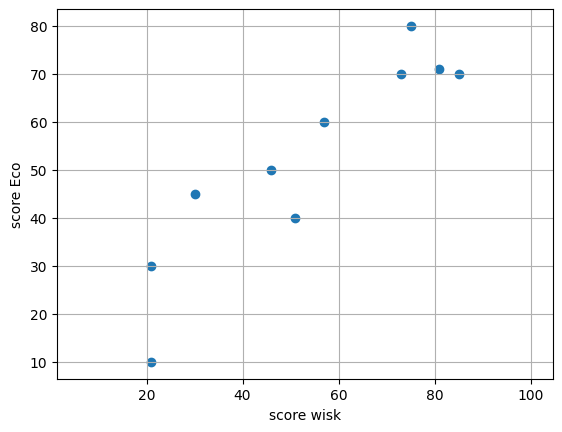

In [8]:
plt.scatter(W,E)
plt.xlabel("score wisk")
plt.ylabel("score Eco")
plt.axis("equal")
plt.grid()
plt.show()

### Oefening 64
Genereer een steekproef met 200 waarnemingen van een variabele met als verdeling $N(2, 1)$.

a) Teken de histogram van deze steekproef.

b) Vind een interval waarin het populatiegemiddelde van een dergelijke steekproef zal liggen met 80% betrouwbaarheid.

(array([0.02772431, 0.02772431, 0.08317294, 0.11089725, 0.12475941,
        0.27724313, 0.33269176, 0.29110529, 0.4158647 , 0.42972686,
        0.38814039, 0.13862157, 0.04158647, 0.04158647, 0.04158647]),
 array([-0.88075487, -0.52006064, -0.15936641,  0.20132783,  0.56202206,
         0.9227163 ,  1.28341053,  1.64410476,  2.004799  ,  2.36549323,
         2.72618746,  3.0868817 ,  3.44757593,  3.80827017,  4.1689644 ,
         4.52965863]),
 <BarContainer object of 15 artists>)

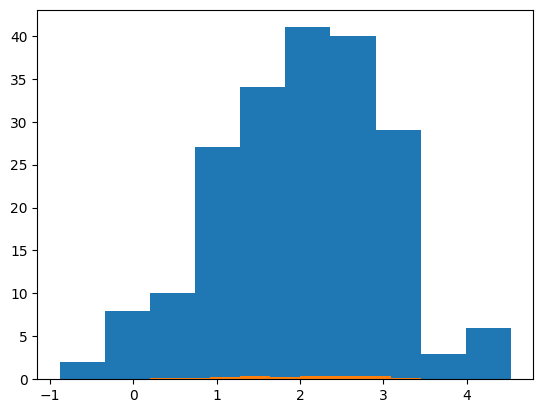

In [9]:
data = np.random.normal(2,1,200)
plt.hist(data)
plt.hist(data,bins=15,density=True)

In [11]:
# sigma niet gekend
tinterval = spstat.t.interval(0.8,len(data)-1,np.mean(data),spstat.sem(data))
print(f"80% betrouwbaarheidsinterval voor mu: ({tinterval[0]:.3f}, {tinterval[1]:.3f})")

# sigma gekend
sigma=1
interval = spstat.norm.interval(0.8,np.mean(data),sigma/np.sqrt(200))
print(f"80% betrouwbaarheidsinterval voor mu: ({interval[0]:.3f}, {interval[1]:.3f})")

80% betrouwbaarheidsinterval voor mu: (1.896, 2.078)
80% betrouwbaarheidsinterval voor mu: (1.896, 2.078)


### Oefening 65
a) Als $x : F(5, 12 \text{ d. f.})$, dan is $P(x < 2) = \dots$

b) Als $y : t(10 \text{ d. f.})$, dan is $P(y > 1) = \dots$ Wat is $a$ als $P(y < a) = 0.15$?

c) Als $z : \text{Bin}(n = 500, p = 0.02)$, dan is $P(z < 12) = \dots$(controleer dit laatste ook met de normale verdeling en vergelijk)

In [12]:
# a
print('P(x<2) = ',spstat.f.cdf(2,15,12))

# b 
print('P(y>1) = 1 - P(y<1) = ', 1-spstat.t.cdf(1,10))
print('a = ',spstat.t.ppf(0.15,10), 'als P(y<a) = 0.15')

# c
print('P(z<12) = ',spstat.binom.cdf(11,500,0.02))

n = 500
p = 0.02
print('np = ',n*p)
print('n(1-p) = ',n*(1-p))
print('P(z<12) = ',spstat.norm.cdf(11.5,n*p,np.sqrt(n*p*(1-p))))

P(x<2) =  0.8839384428956263
P(y>1) = 1 - P(y<1) =  0.17044656615102993
a =  -1.0930580735905253 als P(y<a) = 0.15
P(z<12) =  0.6979347246811096
np =  10.0
n(1-p) =  490.0
P(z<12) =  0.6840866796692541


### Oefening 66
Genereer zelf een steekproef met 100 waarnemingen van lengtes van planken. De leverancier stelt dat de lengtes normaal verdeeld zijn met $\mu = 2$ m en $\sigma = 9$ cm. Onze zaagmachine zaagt van elke plank een deel af met een lengte die normaal verdeeld verondersteld wordt met $\mu = 1.5$ m en $\sigma = 1$ cm. Simuleer dit. Welke verdeling verwacht je voor de lengtes van de overblijvende stukken van de planken als je weet dat de werking van de machine onafhankelijk is van de lengte van de plank. Controleer dit aan de hand van de grafieken van de cumulatieve distributiefuncties (theoretische functie in het rood met een puntlijn).

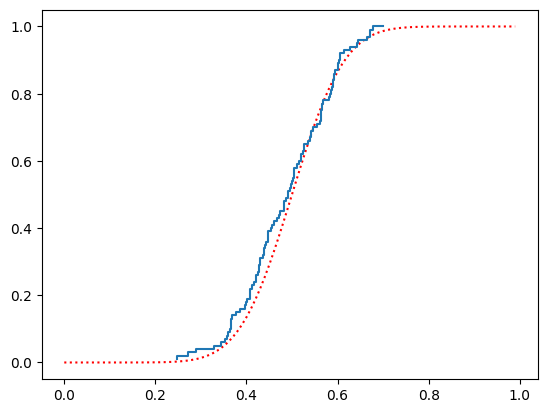

In [3]:
restjes_sim = np.random.normal(2,0.09,100) - np.random.normal(1.5,0.01,100)
x = np.arange(0,1,1/100)
restjes_th = spstat.norm.cdf(x,0.5,np.sqrt(0.09**2+0.01**2))
plt.plot(x,restjes_th, 'r:')
ecdf = empir.ECDF(restjes_sim)
plt.step(ecdf.x,ecdf.y)
plt.show()